# Notebook 1 — CNNs, End to End

**Course 2: Computer Vision and Pretrained Models · Day 1, Session (3 hours)**

Today you build an image classifier from scratch. Tomorrow you throw it away and use someone else's.

That is not a joke — it is the whole point of this course. To understand *why* professionals almost never train image models from scratch, you first have to feel what training from scratch actually costs you. So today we do it properly: real data, a real convolutional network, a real training loop, and an honest evaluation.

By the end of this notebook you will be able to:

1. Load an image dataset from disk and explain every number in a tensor's shape
2. Explain why a plain neural network is the wrong tool for images, and what convolution fixes
3. Build a CNN in PyTorch and compute its output shapes by hand
4. Preprocess and augment images — and know which augmentations would *damage* this particular dataset
5. Write a training loop with validation, and recognise overfitting from the loss curves
6. Save a trained model so a dead Kaggle session doesn't cost you an afternoon

**Your dataset for the entire course:** Weather Image Recognition — 6,862 photographs, 11 weather conditions. You will use this same dataset in all four notebooks, which is what makes tomorrow's comparison meaningful.

---

## Section 0 — Kaggle setup (10 min)

Before running anything, configure the notebook environment:

1. Click **⋮ settings → Accelerator → GPU T4 x2** (or **GPU P100**)
2. Click **⋮ → Internet → On**
3. Click **+ Add Input → Datasets**, search `weather-dataset`, and add **jehanbhathena/weather-dataset**

> **If GPU or Internet is greyed out**, your account is not phone-verified. Go to your Kaggle account settings and verify your phone number. Without this you cannot get a GPU today, and you cannot download pretrained weights tomorrow.

In [1]:
import sys
import torch
import torchvision

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("torchvision :", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
else:
    print("\n*** NO GPU. Go to the ... menu -> Accelerator -> GPU before continuing. ***")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

Python      : 3.12.13
PyTorch     : 2.10.0+cu128
torchvision : 0.25.0+cu128
CUDA available: True
GPU         : Tesla T4

Using device: cuda


Reading the data

In [2]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


DATA_ROOT = Path("/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset")
print("Dataset root:", DATA_ROOT)

class_dirs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f"\nFound {len(class_dirs)} classes:")
for d in class_dirs:
    n = sum(1 for p in d.iterdir() if p.suffix.lower() in IMG_EXT)
    print(f"  {d.name:12s} {n:5d} images")

Dataset root: /kaggle/input/datasets/jehanbhathena/weather-dataset/dataset

Found 11 classes:
  dew            698 images
  fogsmog        851 images
  frost          475 images
  glaze          639 images
  hail           591 images
  lightning      377 images
  rain           526 images
  rainbow        232 images
  rime          1160 images
  sandstorm      692 images
  snow           621 images


---

## Section 1 — Images, tensors, and shapes (20 min)

Every computer vision bug you will ever write is, at bottom, a shape bug. So before any modelling, we get very concrete about what an image *is* once it is inside PyTorch.

Let us open a single file and look at it as a human, then as a machine.

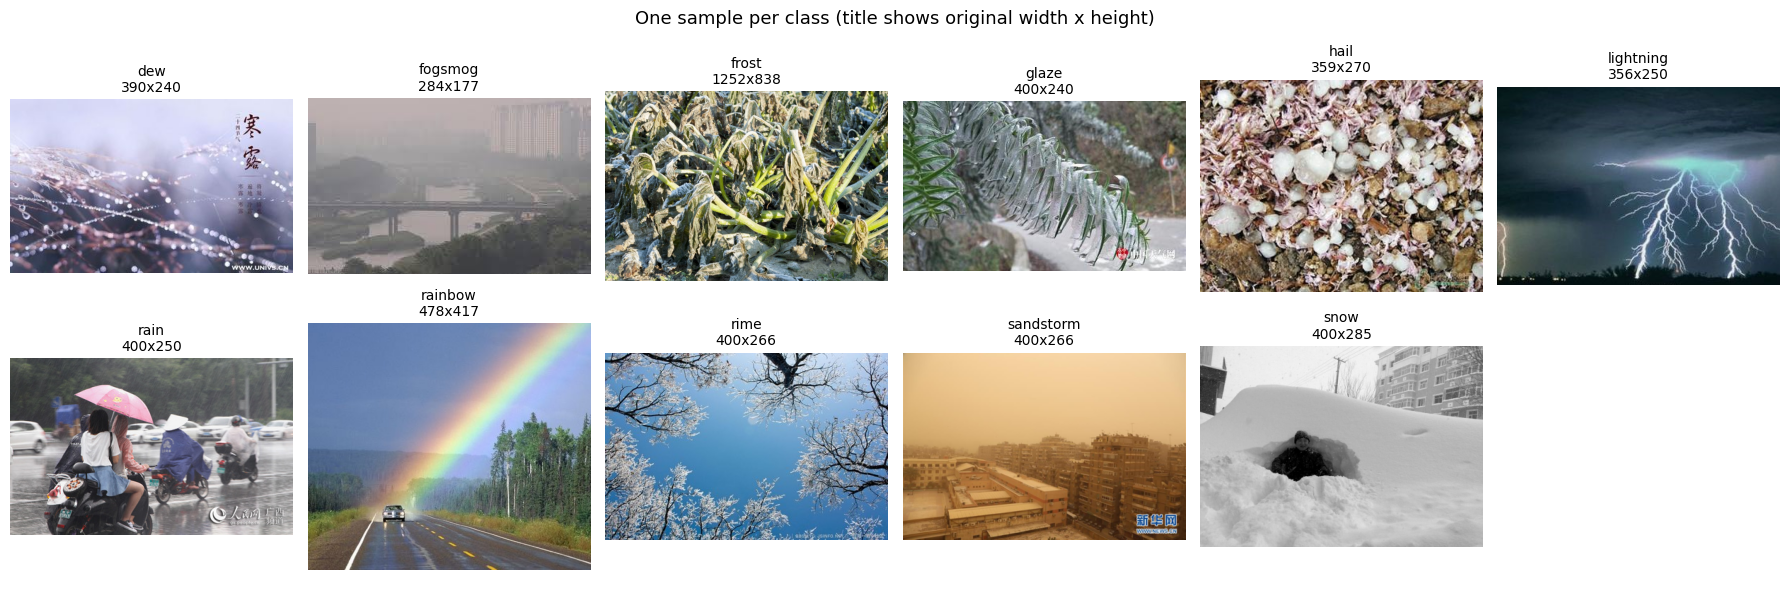

In [3]:
import random
from PIL import Image
import matplotlib.pyplot as plt

random.seed(0)

# Grab one image from each class
samples = []
for d in class_dirs:
    files = [p for p in d.iterdir()]
    samples.append((d.name, random.choice(files)))

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for ax, (name, path) in zip(axes.flat, samples):
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{name}\n{img.size[0]}x{img.size[1]}", fontsize=10)
    ax.axis("off")
for ax in axes.flat[len(samples):]:
    ax.axis("off")
plt.suptitle("One sample per class (title shows original width x height)", fontsize=13)
plt.tight_layout()
plt.show()

**Look at the sizes in those titles.** They are all different. These are photographs scraped from the web, not a tidy academic benchmark where everything is pre-cropped to a neat square.

This matters immediately: a neural network layer has a *fixed* number of weights, so it needs a *fixed* input size. Before anything else, every image must be forced to a common shape. That is the first job of preprocessing, and we will handle it in Section 4.

Now let us convert one image into a tensor and watch what changes.

In [4]:
import numpy as np
import torchvision.transforms as T

name, path = samples[0]
img = Image.open(path).convert("RGB")

print("=== As a PIL image ===")
print("type      :", type(img).__name__)
print("size      :", img.size, "(width, height)")
print("mode      :", img.mode)

arr = np.array(img)
print("\n=== As a NumPy array ===")
print("shape     :", arr.shape, " -> (height, width, channels)")
print("dtype     :", arr.dtype)
print("min / max :", arr.min(), "/", arr.max())

tensor = T.ToTensor()(img)
print("\n=== As a PyTorch tensor ===")
print("shape     :", tuple(tensor.shape), " -> (channels, height, width)")
print("dtype     :", tensor.dtype)
print("min / max :", round(tensor.min().item(), 3), "/", round(tensor.max().item(), 3))

=== As a PIL image ===
type      : Image
size      : (390, 240) (width, height)
mode      : RGB

=== As a NumPy array ===
shape     : (240, 390, 3)  -> (height, width, channels)
dtype     : uint8
min / max : 0 / 255

=== As a PyTorch tensor ===
shape     : (3, 240, 390)  -> (channels, height, width)
dtype     : torch.float32
min / max : 0.0 / 1.0


### Two things changed. Both will bite you later.

**1. The axes were reordered: `H×W×C` became `C×H×W`.**

PIL, NumPy, OpenCV and matplotlib all put channels last. PyTorch puts channels *first*. This single inconsistency is responsible for an enormous share of beginner CV bugs — you pass an array to a model and get a cryptic error about expecting 3 channels but receiving 1200.

Whenever you move an image between libraries, ask yourself which convention you are in. To display a PyTorch tensor with matplotlib you must permute it back:

```python
plt.imshow(tensor.permute(1, 2, 0))   # C,H,W -> H,W,C
```

**2. The values were rescaled: integers `0–255` became floats `0.0–1.0`.**

`ToTensor()` silently divides by 255. Neural networks train badly on large-magnitude inputs, so this rescaling is not cosmetic. In Section 4 we go further and *normalize* — and tomorrow you will see that getting normalization wrong quietly destroys a pretrained model's accuracy without raising a single error.

### The fourth dimension: batches

A model never processes one image. It processes a **batch**, so shapes gain a leading dimension:

| Shape | Meaning |
|---|---|
| `(3, 224, 224)` | one image: 3 channels, 224 tall, 224 wide |
| `(32, 3, 224, 224)` | a batch of 32 such images |
| `(32, 11)` | the model's output: for each of 32 images, 11 class scores |

`(N, C, H, W)` — commit it to memory. Whenever a PyTorch error mentions shapes, your first move is to print the shape and check it against this pattern.

In [5]:
batch = torch.stack([T.ToTensor()(T.Resize((224, 224))(Image.open(p).convert("RGB")))
                     for _, p in samples[:4]])

print("Batch shape:", tuple(batch.shape))
print("  N =", batch.shape[0], "images in the batch")
print("  C =", batch.shape[1], "colour channels")
print("  H =", batch.shape[2], "pixels tall")
print("  W =", batch.shape[3], "pixels wide")
print("\nTotal numbers the model must read:", batch.numel())

Batch shape: (4, 3, 224, 224)
  N = 4 images in the batch
  C = 3 colour channels
  H = 224 pixels tall
  W = 224 pixels wide

Total numbers the model must read: 602112


### How balanced is this dataset?

One more thing to check before modelling — and this one will come back to haunt you in the lab.

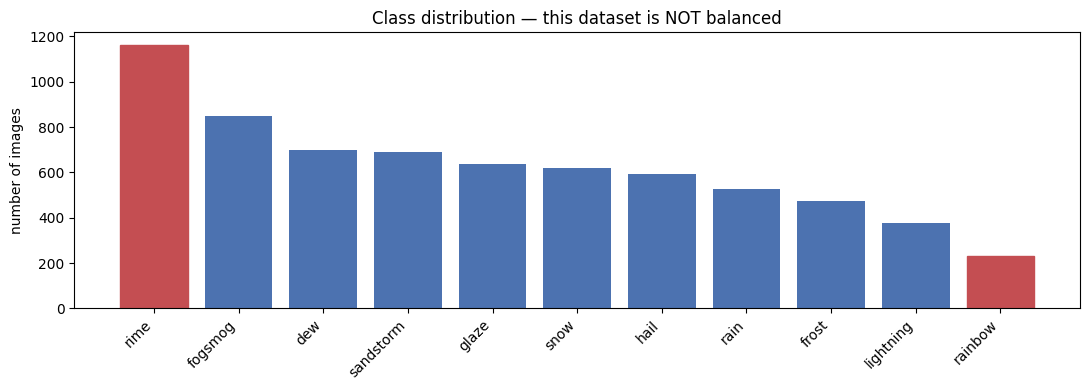

Total images : 6862
Largest class: rime       1160  (16.9%)
Smallest class: rainbow    232  (3.4%)
Imbalance ratio: 5.0x


In [6]:
import pandas as pd

counts = {d.name: sum(1 for p in d.iterdir() if p.suffix.lower() in IMG_EXT)
          for d in class_dirs}
counts = dict(sorted(counts.items(), key=lambda kv: -kv[1]))

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(counts.keys(), counts.values(), color="#4C72B0")
bars[0].set_color("#C44E52")
bars[-1].set_color("#C44E52")
ax.set_ylabel("number of images")
ax.set_title("Class distribution — this dataset is NOT balanced")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

total = sum(counts.values())
biggest, smallest = list(counts.items())[0], list(counts.items())[-1]
print(f"Total images : {total}")
print(f"Largest class: {biggest[0]:10s} {biggest[1]:4d}  ({100*biggest[1]/total:.1f}%)")
print(f"Smallest class: {smallest[0]:9s} {smallest[1]:4d}  ({100*smallest[1]/total:.1f}%)")
print(f"Imbalance ratio: {biggest[1]/smallest[1]:.1f}x")

**Remember this chart.** A model that completely ignores the smallest class — never predicting it even once — loses only a few percent of overall accuracy. It can look like a good model while being useless at exactly the thing you might care about most.

This is why "accuracy" alone is a weak claim, and it is why Section 6 introduces precision and recall. Your lab today is built around this.

---

## Section 2 — Why not just use a normal neural network? (30 min)

You already know how a fully-connected network works from Level 1: flatten the input, multiply by a weight matrix, apply a nonlinearity, repeat.

So let us try exactly that on an image and see what goes wrong.

In [7]:
H = W = 224
C = 3
HIDDEN = 128

input_features = C * H * W
params_layer1 = input_features * HIDDEN + HIDDEN

print(f"Input image      : {C} x {H} x {W}")
print(f"Flattened        : {input_features:,} values")
print(f"Hidden units     : {HIDDEN}")
print(f"Parameters in the FIRST layer alone: {params_layer1:,}")
print(f"Memory (float32) : {params_layer1 * 4 / 1e6:.1f} MB")

print("\nFor comparison, one convolutional layer with 32 filters of size 3x3:")
conv_params = (3 * 3 * C) * 32 + 32
print(f"  Parameters      : {conv_params:,}")
print(f"  Ratio           : {params_layer1 / conv_params:,.0f}x fewer")

Input image      : 3 x 224 x 224
Flattened        : 150,528 values
Hidden units     : 128
Parameters in the FIRST layer alone: 19,267,712
Memory (float32) : 77.1 MB

For comparison, one convolutional layer with 32 filters of size 3x3:
  Parameters      : 896
  Ratio           : 21,504x fewer


### Problem 1: the parameter count explodes

Twelve million parameters — for *one layer* of a network we have not even finished designing. With 5,000 training images, you have roughly 2,500 parameters per training image. A model that large will not learn the concept of "fog"; it will memorise your training set perfectly and fail on anything new.

### Problem 2: flattening destroys spatial structure

Flattening tells the network that pixel `(0, 0)` and pixel `(0, 1)` — physically adjacent, almost certainly part of the same object — are simply features number 0 and number 1. Neighbouring pixels get no special relationship. You have thrown away the single most useful fact about an image: **nearby pixels are related**.

### Problem 3: no translation invariance

Train a fully-connected network on lightning in the top-left corner, and it learns weights specific to *those input positions*. Move the lightning bolt to the bottom-right and it is, as far as the network is concerned, an entirely new pattern it has never seen. Every feature must be re-learned separately for every position it might appear in.

### What convolution fixes

A convolutional layer addresses all three at once with one idea: **a small window of weights that slides across the whole image.**

- **Small.** A 3×3×3 filter is 27 weights, not 12 million. Massive reduction.
- **Local.** It only ever looks at a neighbourhood, so spatial structure is preserved by construction.
- **Shared.** The *same* weights are applied at every position, so a feature learned in one corner is automatically detected everywhere. That is translation invariance, for free.

That is the entire conceptual leap. Everything else in CNN design is engineering detail on top of it.

---

## Section 3 — Convolution, concretely (40 min)

Let us stop describing convolution and actually run one. We will hand-build a filter whose behaviour we can predict, apply it to a real image from our dataset, and look at the result.

Input shape: (1, 1, 320, 320)


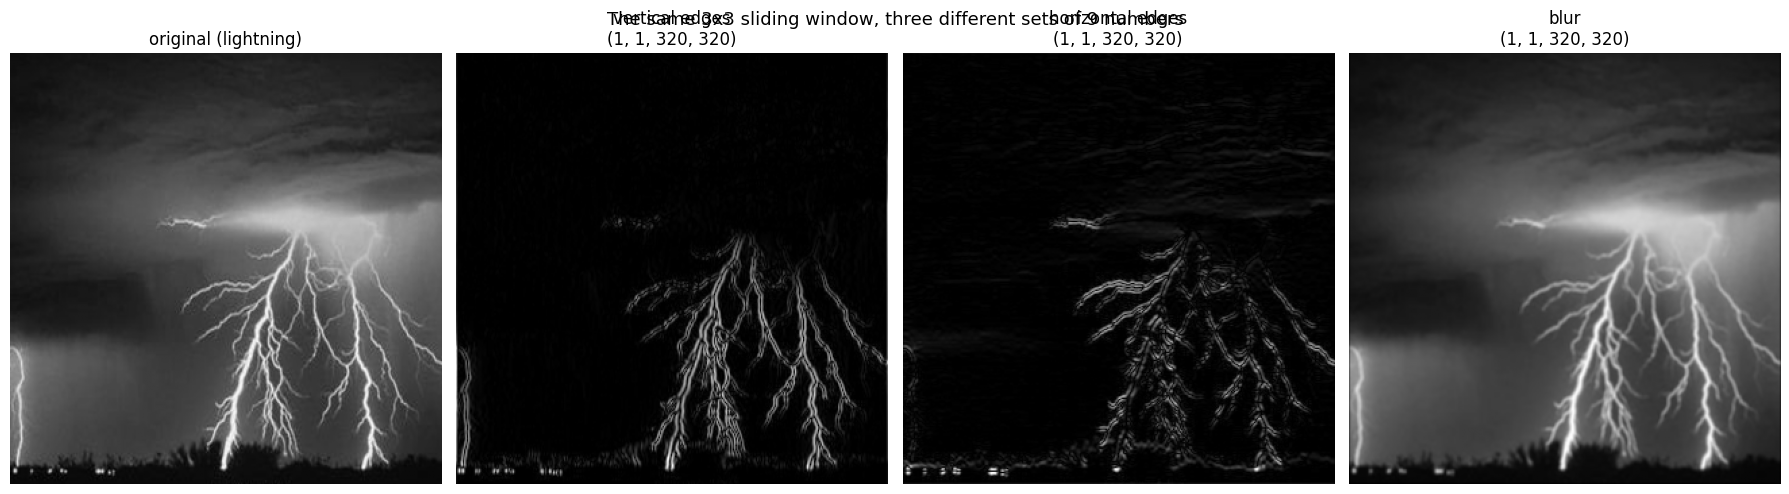

In [8]:
import torch.nn.functional as F

# A real image, as a batch of 1, in greyscale for clarity
img = Image.open(samples[5][1]).convert("RGB").resize((320, 320))
grey = T.functional.rgb_to_grayscale(T.ToTensor()(img))
x = grey.unsqueeze(0)                     # (1, 1, 320, 320)
print("Input shape:", tuple(x.shape))

# Three hand-designed 3x3 filters
filters = {
    "vertical edges": [[-1, 0, 1],
                       [-2, 0, 2],
                       [-1, 0, 1]],
    "horizontal edges": [[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]],
    "blur": [[1/9, 1/9, 1/9],
             [1/9, 1/9, 1/9],
             [1/9, 1/9, 1/9]],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(grey.squeeze(), cmap="gray")
axes[0].set_title(f"original ({samples[5][0]})")
axes[0].axis("off")

for ax, (fname, kernel) in zip(axes[1:], filters.items()):
    k = torch.tensor(kernel, dtype=torch.float32).view(1, 1, 3, 3)
    out = F.conv2d(x, k, padding=1)
    ax.imshow(out.squeeze().abs(), cmap="gray")
    ax.set_title(f"{fname}\n{tuple(out.shape)}")
    ax.axis("off")

plt.suptitle("The same 3x3 sliding window, three different sets of 9 numbers", fontsize=13)
plt.tight_layout()
plt.show()

### That is all a convolution is

Nine numbers, slid across the image, multiplied and summed at each position. Change the nine numbers and you change what the filter responds to — vertical edges, horizontal edges, smoothing.

**Here is the crucial part.** We *chose* those nine numbers by hand. In a CNN, they are **learned parameters**. Training a CNN means gradient descent discovering, on its own, which filters are worth having. Early layers reliably converge on edge and colour-blob detectors much like the ones above; deeper layers combine those into textures, then parts, then objects.

Keep this in mind, because it is the foundation of tomorrow's entire lesson: *if the first layers of every image model learn roughly the same edge detectors, why would you ever train them again from scratch?*

### Output size arithmetic

You must be able to compute this by hand — it is how you debug shape errors.

$$H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1$$

where `k` = kernel size, `p` = padding, `s` = stride.

Two cases cover almost everything you will write:

| Config | Effect | Use |
|---|---|---|
| `k=3, p=1, s=1` | size unchanged | the default conv layer |
| `k=2, s=2` (max-pool) | size is 1/4 of original | downsampling between blocks |

In [9]:
def conv_out(h_in, k, p=0, s=1):
    return (h_in + 2*p - k) // s + 1

print("Verify against the formula:")
for h_in, k, p, s in [(224, 3, 1, 1), (224, 3, 0, 1), (224, 2, 0, 2), (224, 7, 3, 2)]:
    calc = conv_out(h_in, k, p, s)
    real = F.conv2d(torch.zeros(1, 1, h_in, h_in),
                    torch.zeros(1, 1, k, k), padding=p, stride=s).shape[-1]
    flag = "OK" if calc == real else "MISMATCH"
    print(f"  in={h_in:3d} k={k} p={p} s={s}  ->  formula {calc:3d}, actual {real:3d}   {flag}")

Verify against the formula:
  in=224 k=3 p=1 s=1  ->  formula 224, actual 224   OK
  in=224 k=3 p=0 s=1  ->  formula 222, actual 222   OK
  in=224 k=2 p=0 s=2  ->  formula 112, actual 112   OK
  in=224 k=7 p=3 s=2  ->  formula 112, actual 112   OK


### Channels: many filters at once

A conv layer does not learn one filter, it learns many. `nn.Conv2d(3, 32, kernel_size=3)` learns **32** different 3×3×3 filters, and produces 32 output feature maps — one per filter. Those 32 maps become the "channels" fed to the next layer, which then learns filters of shape 3×3×**32**.

So the standard CNN pattern is: **spatial size shrinks, channel count grows.** You trade "where things are" for "what things are".

Now we build the network.

In [10]:
import torch.nn as nn

class SmallCNN(nn.Module):
    """A deliberately simple CNN: four blocks, each halving the spatial size."""

    def __init__(self, num_classes: int):
        super().__init__()

        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),  # size unchanged
                nn.BatchNorm2d(out_ch),                              # stabilises training
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),                                     # size halved
            )

        self.features = nn.Sequential(
            block(3,   32),    # 224 -> 112
            block(32,  64),    # 112 -> 56
            block(64,  128),   # 56  -> 28
            block(128, 256),   # 28  -> 14
        )
        # Collapse whatever spatial size remains down to 1x1.
        # This makes the classifier independent of input resolution.
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = SmallCNN(num_classes=len(class_dirs))
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {n_params:,}")
print(f"Compare with the 12.8 million in ONE fully-connected layer earlier.")

SmallCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0)

### Trace the shapes yourself

Before running the next cell, predict what it will print. If your prediction is wrong, work out why — this skill is worth more than memorising any architecture.

In [11]:
x = torch.randn(8, 3, 224, 224)
print(f"{'input':<28} {tuple(x.shape)}")

h = x
for i, blk in enumerate(model.features):
    h = blk(h)
    print(f"{'after block ' + str(i+1):<28} {tuple(h.shape)}")

h = model.pool(h)
print(f"{'after adaptive pool':<28} {tuple(h.shape)}")

out = model.classifier(h)
print(f"{'after classifier (logits)':<28} {tuple(out.shape)}")
print(f"\nOne row of 11 numbers per image. Highest number = predicted class.")

input                        (8, 3, 224, 224)
after block 1                (8, 32, 112, 112)
after block 2                (8, 64, 56, 56)
after block 3                (8, 128, 28, 28)
after block 4                (8, 256, 14, 14)
after adaptive pool          (8, 256, 1, 1)
after classifier (logits)    (8, 11)

One row of 11 numbers per image. Highest number = predicted class.


---

## Section 4 — Preprocessing and augmentation (35 min)

### Preprocessing: making the data usable at all

Three steps, always in this order:

1. **Resize** — force every image to one fixed size, because layers have fixed weight counts
2. **ToTensor** — convert to `C×H×W` floats in `[0, 1]`
3. **Normalize** — shift and scale each channel to be roughly centred on zero

Why normalize? Gradient descent converges far better when inputs are centred and comparably scaled. Inputs stuck in `[0, 1]` are all positive, which biases the gradients of the first layer in a way that slows learning.

For a model trained from scratch, the exact constants barely matter. **Tomorrow they will matter enormously** — a pretrained model expects the precise statistics its original training used, and feeding it anything else degrades it silently.

In [12]:
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]   # ImageNet channel means
STD  = [0.229, 0.224, 0.225]   # ImageNet channel std devs

eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

demo = Image.open(samples[0][1]).convert("RGB")
before = T.ToTensor()(T.Resize((IMG_SIZE, IMG_SIZE))(demo))
after = eval_tf(demo)

print(f"{'':<12}{'min':>8}{'max':>8}{'mean':>8}{'std':>8}")
print(f"{'before':<12}{before.min():8.2f}{before.max():8.2f}{before.mean():8.2f}{before.std():8.2f}")
print(f"{'after':<12}{after.min():8.2f}{after.max():8.2f}{after.mean():8.2f}{after.std():8.2f}")
print("\nAfter normalization values straddle zero. That is what we want.")

                 min     max    mean     std
before          0.04    1.00    0.65    0.24
after          -1.86    2.64    0.87    1.11

After normalization values straddle zero. That is what we want.


### Augmentation: manufacturing more data

We have ~5,000 training images and a model with 300,000 parameters. That model will memorise. **Augmentation** fights this by randomly perturbing each training image every time it is seen, so the model never gets the identical input twice and is forced to learn the general concept rather than specific pixels.

**The rule that students break most often:**

> Augment the **training** set only. Never the validation or test set.

Validation exists to estimate real-world performance. If you randomise it, your measurement becomes noisy and you have made your only source of truth unreliable.

### Choosing augmentations is a judgement call about *your* data

Augmentation is not a fixed recipe you copy. Every transform encodes a claim: *"this change should not alter the correct label."* If that claim is false for your dataset, you are actively teaching the model something wrong.

For weather photographs:

| Transform | Verdict | Reason |
|---|---|---|
| `RandomHorizontalFlip` | **Safe** | A mirrored fog bank is still fog |
| `RandomResizedCrop` | **Safe, valuable** | Simulates different framing and zoom |
| `RandomRotation(15)` | **Safe in moderation** | Cameras are not always level |
| `ColorJitter` — mild | **Use with care** | Simulates exposure differences |
| `ColorJitter` — aggressive | **Harmful here** | Colour *is* the signal for `rainbow` and `sandstorm`. Destroy the colour and you destroy the label |
| `RandomVerticalFlip` | **Harmful** | Upside-down skies do not occur. You would spend model capacity learning an impossible world |
| `Grayscale` | **Harmful** | Removes the only cue distinguishing several classes |

Note that the last three would be perfectly reasonable on a different dataset — satellite imagery has no canonical "up", and grayscale is fine for X-rays. **The dataset decides.**

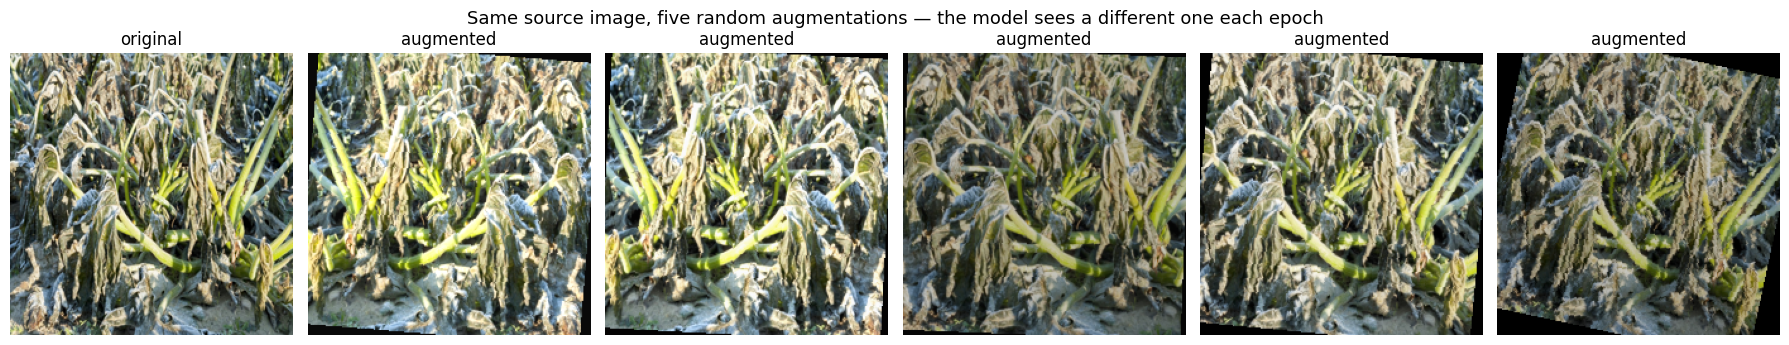

In [13]:
train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),  # deliberately mild
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

def denorm(t):
    """Undo Normalize so we can look at the image."""
    m = torch.tensor(MEAN).view(3, 1, 1)
    s = torch.tensor(STD).view(3, 1, 1)
    return (t * s + m).clamp(0, 1).permute(1, 2, 0)

src = Image.open(samples[2][1]).convert("RGB")
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
axes[0].imshow(src.resize((IMG_SIZE, IMG_SIZE)))
axes[0].set_title("original")
axes[0].axis("off")
for ax in axes[1:]:
    ax.imshow(denorm(train_tf(src)))
    ax.set_title("augmented")
    ax.axis("off")
plt.suptitle("Same source image, five random augmentations — the model sees a different one each epoch",
             fontsize=13)
plt.tight_layout()
plt.show()

---

## Section 5 — Training and validation (30 min)

### Splitting the data

This dataset ships as one flat pile of class folders with no train/test split. You must make your own — and it must be **stratified**, meaning each split preserves the original class proportions. With `rainbow` at only ~3% of the data, a careless random split could easily leave it barely represented in validation, making your measurements meaningless.

Three splits, each with a distinct job:

| Split | Share | Purpose |
|---|---|---|
| **train** | 70% | gradients are computed from this |
| **validation** | 15% | watched during training; used to choose epochs and hyperparameters |
| **test** | 15% | touched **once**, at the very end |

Keeping test separate is not bureaucracy. Every time you look at a result and change something, you leak a little information about that data into your model. Test data you have peeked at repeatedly is no longer an honest estimate of real-world performance.

In [14]:
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

full = ImageFolder(DATA_ROOT)
CLASSES = full.classes
targets = np.array(full.targets)
print(f"{len(full)} images, {len(CLASSES)} classes: {CLASSES}")

idx = np.arange(len(full))
train_idx, tmp_idx = train_test_split(idx, test_size=0.30, stratify=targets, random_state=42)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50,
                                     stratify=targets[tmp_idx], random_state=42)

print(f"\ntrain {len(train_idx):5d}   val {len(val_idx):5d}   test {len(test_idx):5d}")

# Verify stratification held
print(f"\n{'class':<12}{'overall %':>11}{'train %':>10}{'val %':>9}{'test %':>9}")
for c, name in enumerate(CLASSES):
    print(f"{name:<12}"
          f"{100*(targets == c).mean():10.1f}%"
          f"{100*(targets[train_idx] == c).mean():9.1f}%"
          f"{100*(targets[val_idx] == c).mean():8.1f}%"
          f"{100*(targets[test_idx] == c).mean():8.1f}%")

6862 images, 11 classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']

train  4803   val  1029   test  1030

class         overall %   train %    val %   test %
dew               10.2%     10.2%    10.1%    10.2%
fogsmog           12.4%     12.4%    12.3%    12.4%
frost              6.9%      6.9%     7.0%     6.9%
glaze              9.3%      9.3%     9.3%     9.3%
hail               8.6%      8.6%     8.6%     8.6%
lightning          5.5%      5.5%     5.5%     5.4%
rain               7.7%      7.7%     7.7%     7.7%
rainbow            3.4%      3.4%     3.4%     3.4%
rime              16.9%     16.9%    16.9%    16.9%
sandstorm         10.1%     10.1%    10.1%    10.1%
snow               9.0%      9.1%     9.0%     9.0%


### Applying different transforms to different splits

A subtlety: `ImageFolder` holds one transform, but train needs augmentation while val and test must not have it. The clean fix is a tiny wrapper that pairs a set of indices with its own transform.

In [15]:
from torch.utils.data import Dataset

class SplitDataset(Dataset):
    """A subset of an ImageFolder with its own transform."""

    def __init__(self, base: ImageFolder, indices, transform):
        self.base = base
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label


BATCH_SIZE = 32
NUM_WORKERS = 2

train_ds = SplitDataset(full, train_idx, train_tf)   # augmented
val_ds   = SplitDataset(full, val_idx,   eval_tf)    # NOT augmented
test_ds  = SplitDataset(full, test_idx,  eval_tf)    # NOT augmented

common = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **common)
val_loader   = DataLoader(val_ds,   shuffle=False, **common)
test_loader  = DataLoader(test_ds,  shuffle=False, **common)

xb, yb = next(iter(train_loader))
print("One batch of images:", tuple(xb.shape))
print("One batch of labels:", tuple(yb.shape), "->", yb[:8].tolist())

One batch of images: (32, 3, 224, 224)
One batch of labels: (32,) -> [5, 8, 1, 0, 3, 4, 1, 2]


### The training loop

Every PyTorch training loop you will ever write is this, plus decoration:

```
for each batch:
    optimizer.zero_grad()      # clear last step's gradients
    output = model(x)          # forward
    loss = criterion(output, y)
    loss.backward()            # compute gradients
    optimizer.step()           # update weights
```

Two calls you must never omit:

- **`model.train()` / `model.eval()`** — switches BatchNorm and Dropout between training and inference behaviour. Forgetting `model.eval()` produces wrong, unstable validation scores.
- **`torch.no_grad()`** — during validation, tells PyTorch not to build the graph for backprop. Saves memory and time; you are not learning from this data.

In [16]:
import time

def run_epoch(model, loader, criterion, optimizer=None):
    """One pass over loader. Pass optimizer to train, omit it to evaluate."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            if training:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += y.size(0)
    return total_loss / n, correct / n


def fit(model, train_loader, val_loader, epochs, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc, best_state = 0.0, None

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)

        for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc]):
            history[k].append(v)

        star = ""
        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            star = "  <- best"

        print(f"epoch {ep:2d}/{epochs}  "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f}   |   "
              f"val loss {va_loss:.3f} acc {va_acc:.3f}   "
              f"({time.time()-t0:.0f}s){star}")

    if best_state:
        model.load_state_dict(best_state)
    return model, history

Now train. We use 8 epochs here so the session keeps moving — enough to see the trend clearly. In the lab you will train longer.

In [17]:
torch.manual_seed(42)
model = SmallCNN(num_classes=len(CLASSES))
model, history = fit(model, train_loader, val_loader, epochs=15, lr=1e-3)

epoch  1/15  train loss 1.420 acc 0.521   |   val loss 1.215 acc 0.563   (54s)  <- best
epoch  2/15  train loss 1.237 acc 0.570   |   val loss 1.252 acc 0.572   (33s)  <- best
epoch  3/15  train loss 1.184 acc 0.602   |   val loss 1.156 acc 0.595   (33s)  <- best
epoch  4/15  train loss 1.119 acc 0.614   |   val loss 1.287 acc 0.582   (33s)
epoch  5/15  train loss 1.068 acc 0.627   |   val loss 0.989 acc 0.651   (34s)  <- best
epoch  6/15  train loss 1.028 acc 0.648   |   val loss 1.099 acc 0.654   (33s)  <- best
epoch  7/15  train loss 0.989 acc 0.672   |   val loss 1.094 acc 0.653   (34s)
epoch  8/15  train loss 0.954 acc 0.676   |   val loss 0.918 acc 0.712   (34s)  <- best
epoch  9/15  train loss 0.961 acc 0.671   |   val loss 0.933 acc 0.694   (35s)
epoch 10/15  train loss 0.934 acc 0.683   |   val loss 0.912 acc 0.689   (34s)
epoch 11/15  train loss 0.900 acc 0.698   |   val loss 0.828 acc 0.714   (32s)  <- best
epoch 12/15  train loss 0.885 acc 0.704   |   val loss 0.810 acc 0.7

### Reading the curves

This plot is the most important diagnostic you have. Learn to read it at a glance.

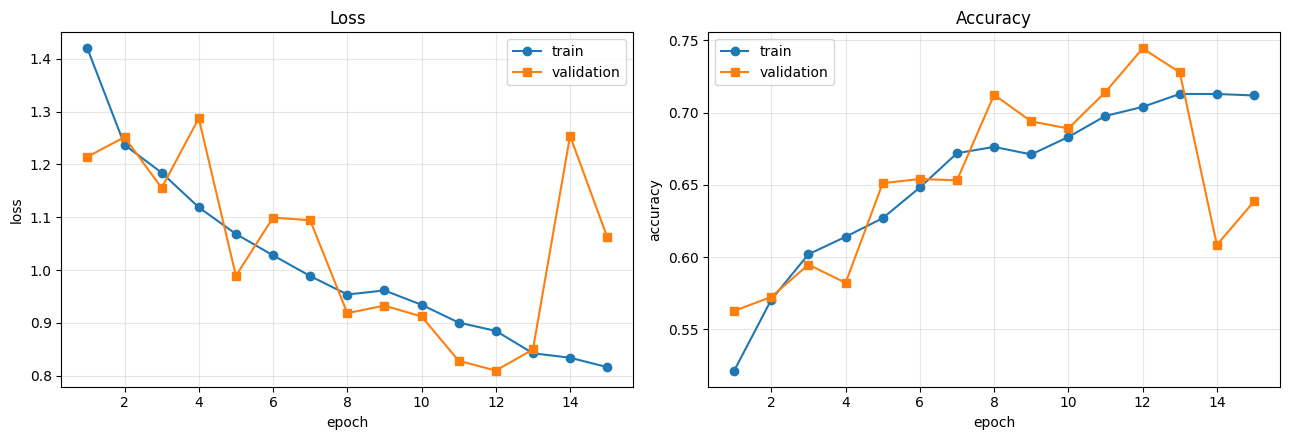

Final train accuracy : 71.2%
Final val accuracy   : 63.8%
Generalisation gap   : 7.3%


In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
ep = range(1, len(history["train_loss"]) + 1)

a1.plot(ep, history["train_loss"], "o-", label="train")
a1.plot(ep, history["val_loss"], "s-", label="validation")
a1.set_xlabel("epoch"); a1.set_ylabel("loss"); a1.set_title("Loss")
a1.legend(); a1.grid(alpha=0.3)

a2.plot(ep, history["train_acc"], "o-", label="train")
a2.plot(ep, history["val_acc"], "s-", label="validation")
a2.set_xlabel("epoch"); a2.set_ylabel("accuracy"); a2.set_title("Accuracy")
a2.legend(); a2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

gap = history["train_acc"][-1] - history["val_acc"][-1]
print(f"Final train accuracy : {history['train_acc'][-1]:.1%}")
print(f"Final val accuracy   : {history['val_acc'][-1]:.1%}")
print(f"Generalisation gap   : {gap:.1%}")

**What to look for:**

| Pattern | Diagnosis | Action |
|---|---|---|
| Both losses falling, curves close together | Healthy — still learning | Train longer |
| Train loss falling, **val loss rising** | **Overfitting** — memorising the training set | Stop early, more augmentation, more data |
| Both flat and high | Underfitting | Bigger model, higher learning rate, train longer |
| Val curve jumping wildly | Learning rate too high, or validation set too small | Lower LR |

Note that `fit()` keeps a snapshot of the weights from the **best validation epoch**, not the last. If a model peaks at epoch 5 and then degrades, you want epoch 5's weights. This is the simplest useful form of early stopping.

---

## Section 6 — Evaluation, and why accuracy is not enough (15 min)

You now have a number. Before trusting it, recall the class distribution from Section 1.

In [19]:
test_loss, test_acc = run_epoch(model, test_loader, nn.CrossEntropyLoss())
print(f"TEST ACCURACY: {test_acc:.1%}")

majority = max(counts.values()) / total
print(f"\nAlways predicting the largest class would get: {majority:.1%}")
print(f"Random guessing would get:                    {1/len(CLASSES):.1%}")

TEST ACCURACY: 71.2%

Always predicting the largest class would get: 16.9%
Random guessing would get:                    9.1%


Accuracy answers exactly one question: *what fraction of predictions were right?* It cannot tell you:

- Whether the model ever predicts `rainbow` **at all**
- Whether errors are spread evenly or concentrated in a few confusable classes
- Whether it is cautious or reckless about any particular class

For that you need three tools, which you will apply in full in today's lab:

**Confusion matrix** — a grid where entry `(i, j)` counts images of true class `i` predicted as class `j`. The diagonal is correct predictions; everything off-diagonal tells you *which* mistakes, not just how many.

**Precision** = of everything predicted class X, what fraction really was X?
→ Answers *"when it says rainbow, can I believe it?"*

**Recall** = of everything that truly is class X, what fraction did we find?
→ Answers *"how many rainbows did it miss?"*

These trade off. A model that predicts `rainbow` only when absolutely certain has high precision and terrible recall. **F1** is their harmonic mean, and averaging matters enormously here:

- **macro** average treats all 11 classes equally — a failed `rainbow` hurts as much as a failed `rime`
- **weighted** average weights by class size — failures on rare classes are largely hidden

> A large gap between macro and weighted F1 is a direct signal that your model is neglecting the small classes.

Here is a preview. The lab is where you do this properly.

In [20]:
from sklearn.metrics import classification_report

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        y_pred.extend(model(x.to(device)).argmax(1).cpu().tolist())
        y_true.extend(y.tolist())

print(classification_report(y_true, y_pred, target_names=CLASSES,
                            digits=3, zero_division=0))

              precision    recall  f1-score   support

         dew      0.717     0.819     0.764       105
     fogsmog      0.847     0.820     0.833       128
       frost      0.500     0.606     0.548        71
       glaze      0.548     0.354     0.430        96
        hail      0.716     0.764     0.739        89
   lightning      0.740     0.964     0.837        56
        rain      0.662     0.570     0.612        79
     rainbow      0.742     0.657     0.697        35
        rime      0.669     0.908     0.771       174
   sandstorm      0.880     0.846     0.863       104
        snow      0.829     0.312     0.453        93

    accuracy                          0.712      1030
   macro avg      0.714     0.693     0.686      1030
weighted avg      0.719     0.712     0.698      1030



Scan the `recall` column and find the worst class. Compare it against that class's size in the Section 1 chart. In today's lab you will investigate whether that relationship holds across all 11 classes.

---

## Section 7 — Saving your work (5 min)

**Kaggle sessions die.** They time out, they get restarted, and everything in memory vanishes. A model you trained for fifteen minutes and did not save is a model you must train again.

Save the **`state_dict`** — a plain dictionary mapping layer names to weight tensors — rather than the model object. Saving the object pickles your class definition too, which breaks as soon as you edit the code.

`/kaggle/working/` is the one writable directory, and its contents persist as notebook output.

In [21]:
from pathlib import Path

OUT = Path("/kaggle/working")
ckpt_path = OUT / "smallcnn_baseline.pt"

torch.save({
    "model_state": model.state_dict(),
    "classes": CLASSES,
    "img_size": IMG_SIZE,
    "test_acc": test_acc,
}, ckpt_path)

print(f"Saved to {ckpt_path}  ({ckpt_path.stat().st_size/1e6:.1f} MB)")

# Reload it into a fresh model to prove it round-trips
reloaded = SmallCNN(num_classes=len(CLASSES))
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
reloaded.load_state_dict(ckpt["model_state"])
reloaded = reloaded.to(device)

_, acc_check = run_epoch(reloaded, test_loader, nn.CrossEntropyLoss())
print(f"Reloaded model test accuracy: {acc_check:.1%}  (should match {test_acc:.1%})")

Saved to /kaggle/working/smallcnn_baseline.pt  (1.6 MB)
Reloaded model test accuracy: 71.2%  (should match 71.2%)


Tomorrow we go much deeper into what a `state_dict` really is — because **loading pretrained weights is this exact operation**, just with someone else's dictionary instead of your own.

---

## Summary

| Concept | Takeaway |
|---|---|
| Tensor shapes | `(N, C, H, W)`. PyTorch is channels-first; almost everything else is channels-last |
| Why CNNs | Small, local, weight-shared filters beat fully-connected layers on all three failure modes |
| Convolution | A sliding window of learned numbers. Early layers learn edge detectors |
| Output sizes | `(H + 2p − k)/s + 1`. Learn it; it is how you debug |
| Preprocessing | Resize → ToTensor → Normalize, in that order |
| Augmentation | Train split only. Every transform is a claim about your data — check it holds |
| Splits | Stratified. Test set touched once |
| Curves | Train loss down + val loss up = overfitting |
| Metrics | Accuracy hides failures on small classes. Use precision, recall, macro-F1 |
| Saving | Save `state_dict`, not the model object |

### Now go to Task 1

You will build and train this CNN yourself, run it **with and without augmentation**, and evaluate it properly with a confusion matrix and per-class metrics.

**Write down your final test accuracy.** Tomorrow you will beat it by a very large margin, and the size of that gap is the entire point of this course.